# 16 — 2mu2e MC and Data ABCD closure with Mu-LJ isolation 0.50

Focused validation of the 2mu2e ABCD method. The presentation order is intentional:

1. inspect B/C/D yields and the $B \times C / D$ prediction without A;
2. inspect nominal closure;
3. test one-axis and two-dimensional threshold stability.

MC closure is shown in SR and VR-invDisplaced. Data closure is shown only in VR-invDisplaced. Data SR A is never accessed. The nominal boundary is $(\mathrm{Mu\text{-}LJ}, \mathrm{EGM\text{-}LJ})=(0.50, 0.25)$, and threshold scans cover 0.25 through 1.00 on both axes.

In [1]:
import gc
import sys
from pathlib import Path

search_roots = [Path.cwd(), *Path.cwd().parents]
SIDM_DIR = next((path for path in search_roots if path.name == "sidm"), None)
assert SIDM_DIR is not None, "Could not locate the sidm repository root"
if str(SIDM_DIR.parent) not in sys.path:
    sys.path.insert(1, str(SIDM_DIR.parent))

import coffea.util
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if int(np.__version__.split(".")[0]) < 2:
    import numpy.core as _numpy_core
    import numpy.core.numeric as _numpy_numeric
    sys.modules.setdefault("numpy._core", _numpy_core)
    sys.modules.setdefault("numpy._core.numeric", _numpy_numeric)

%matplotlib inline


## 1. Inputs and analysis scope

In [2]:
STUDY_DIR = Path.cwd()
if not (STUDY_DIR / "ABCD_golden_hotspot_iso025_v1_bkg_merged_samples_v1").is_dir():
    STUDY_DIR = Path("studies/ABCD_Study")
assert STUDY_DIR.is_dir(), "Run from the repository root or studies/ABCD_Study"
BKG_INPUT_DIR = STUDY_DIR / "ABCD_golden_hotspot_iso025_v1_bkg_merged_samples_v1"
DATA_INPUT_DIR = STUDY_DIR / "ABCD_golden_hotspot_iso025_v1_data_merged_samples_v1"
HIST_NAME = "mulj_egmlj_iso"
TOPOLOGY = "2mu2e"
NOMINAL_CUTS = (0.50, 0.25)
SCAN_VALUES = np.array([0.25, 0.30, 0.40, 0.50, 0.60, 0.75, 1.00])
X_LABEL = "Mu-LJ Isolation"
Y_LABEL = "EGM-LJ Isolation"
BACKGROUND_ORDER = ["QCD", "DY", "TTJets", "Diboson"]

CHANNELS = {
    "SR": "test_SR_2mu2e_spread_cosAlpha_mu_veto",
    "VR-invDisplaced": "test_VR_2mu2e_invDisplaced_spread_cosAlpha_mu_veto",
}

assert np.all((SCAN_VALUES >= 0.25) & (SCAN_VALUES <= 1.00))
assert all(cut in SCAN_VALUES for cut in NOMINAL_CUTS)
assert set(CHANNELS) == {"SR", "VR-invDisplaced"}

def classify_sample(sample):
    if sample.startswith("DoubleMuon"): return "Data"
    if sample.startswith("QCD_"): return "QCD"
    if sample.startswith("DYJetsTo"): return "DY"
    if sample.startswith("TTJets"): return "TTJets"
    if sample in {"WW", "WZ", "ZZ"}: return "Diboson"
    return "Other"

samples_bkg = sorted(path.stem for path in BKG_INPUT_DIR.glob("*.coffea"))
samples_data = sorted(path.stem for path in DATA_INPUT_DIR.glob("*.coffea"))
assert samples_bkg, f"No background files found in {BKG_INPUT_DIR}"
assert samples_data, f"No data files found in {DATA_INPUT_DIR}"
print(f"Background files: {len(samples_bkg)}; Data files: {len(samples_data)}")


Background files: 18; Data files: 68


In [3]:
outputs = {}
for input_dir, samples in [(BKG_INPUT_DIR, samples_bkg), (DATA_INPUT_DIR, samples_data)]:
    for sample in samples:
        try:
            loaded = coffea.util.load(input_dir / f"{sample}.coffea")
            payload = loaded.get("out", loaded)[sample]
            outputs[sample] = payload["hists"][HIST_NAME]
        except Exception as error:
            print(f"**** Failed to load {sample}: {error}")
            outputs.pop(sample, None)
        finally:
            loaded = payload = None
            gc.collect()

sample_groups = {}
for sample in outputs:
    sample_groups.setdefault(classify_sample(sample), []).append(sample)
sample_groups["BKG total"] = sum(
    (sample_groups.get(group, []) for group in BACKGROUND_ORDER), []
)

for sample, hist in outputs.items():
    available = set(hist.axes["channel"])
    missing = set(CHANNELS.values()) - available
    assert not missing, f"{sample}/{HIST_NAME} missing channels: {sorted(missing)}"

print({group: len(samples) for group, samples in sample_groups.items()})


{'DY': 2, 'QCD': 12, 'TTJets': 1, 'Diboson': 3, 'Data': 68, 'BKG total': 18}


## 2. ABCD helpers

In [4]:
def sample_hist(sample, selection):
    return outputs[sample][{"channel": CHANNELS[selection]}]

def group_hist(group, selection):
    members = [group] if group in outputs else sample_groups.get(group, [])
    hists = [sample_hist(sample, selection) for sample in members]
    if not hists:
        return None
    total = hists[0].copy()
    for hist in hists[1:]:
        total = total + hist
    return total

def values_variances(h2d):
    # Fold overflow into the last visible isolation-fail bin; exclude underflow.
    values = np.asarray(h2d.values(flow=True), dtype=float).copy()
    variances = h2d.variances(flow=True)
    variances = (np.clip(values, 0, None) if variances is None
                 else np.asarray(variances, dtype=float).copy())
    values[-2, :] += values[-1, :]
    variances[-2, :] += variances[-1, :]
    values, variances = values[:-1, :], variances[:-1, :]
    values[:, -2] += values[:, -1]
    variances[:, -2] += variances[:, -1]
    values, variances = values[:, :-1], variances[:, :-1]
    return values[1:, 1:], variances[1:, 1:]

def abcd_masks(h2d, xcut, ycut):
    x = np.asarray(h2d.axes[0].centers)[:, None]
    y = np.asarray(h2d.axes[1].centers)[None, :]
    return {
        "A": (x < xcut) & (y < ycut),
        "B": (x >= xcut) & (y < ycut),
        "C": (x < xcut) & (y >= ycut),
        "D": (x >= xcut) & (y >= ycut),
    }

def region_stats(h2d, cuts):
    values, variances = values_variances(h2d)
    result = {}
    for region, mask in abcd_masks(h2d, *cuts).items():
        value = float(values[mask].sum())
        variance = float(np.clip(variances[mask].sum(), 0, None))
        error = np.sqrt(variance)
        result[region] = {
            "yield": value, "error": error,
            "neff": value**2 / variance if variance > 0 else np.nan,
        }
    return result

def prediction(stats):
    b, c, d = (stats[region]["yield"] for region in "BCD")
    eb, ec, ed = (stats[region]["error"] for region in "BCD")
    if d <= 0 or not np.all(np.isfinite([b, eb, c, ec, d, ed])):
        return np.nan, np.nan
    pred = b * c / d
    terms = [(eb / b)**2 if b else 0, (ec / c)**2 if c else 0, (ed / d)**2]
    return pred, abs(pred) * np.sqrt(sum(terms))

def closure_row(h2d, cuts):
    stats = region_stats(h2d, cuts)
    pred, pred_err = prediction(stats)
    obs, obs_err = stats["A"]["yield"], stats["A"]["error"]
    kappa = obs / pred if pred > 0 else np.nan
    kappa_err = (abs(kappa) * np.sqrt((obs_err / obs)**2 + (pred_err / pred)**2)
                 if obs > 0 and pred > 0 else np.nan)
    pull_denominator = np.sqrt(obs_err**2 + pred_err**2)
    pull = (obs - pred) / pull_denominator if pull_denominator > 0 else np.nan
    row = {"xcut": cuts[0], "ycut": cuts[1],
           "A_pred": pred, "A_pred_err": pred_err,
           "kappa": kappa, "kappa_err": kappa_err, "pull": pull}
    for region in "ABCD":
        for field in ("yield", "error", "neff"):
            row[f"{region}_{field}"] = stats[region][field]
    finite_neff = [stats[r]["neff"] for r in "ABCD" if np.isfinite(stats[r]["neff"])]
    row["min_neff"] = min(finite_neff) if finite_neff else np.nan
    row["relative_pred_err"] = pred_err / pred if pred > 0 else np.nan
    row["min_control_yield"] = min(stats[r]["yield"] for r in "BCD")
    return row


## 3. B/C/D yields and prediction before closure

This table intentionally excludes the observed A yield, $\kappa$, and pull.

In [5]:
TARGETS = (
    ("SR", "BKG total", "MC SR"),
    ("VR-invDisplaced", "BKG total", "MC VR-invDisplaced"),
    ("VR-invDisplaced", "Data", "Data VR-invDisplaced"),
)
assert not any(selection == "SR" and group == "Data" for selection, group, _ in TARGETS)

nominal_rows = []
for selection, group, label in TARGETS:
    hist = group_hist(group, selection)
    assert hist is not None, f"Missing histogram for {label}"
    nominal_rows.append({"sample": label, **closure_row(hist, NOMINAL_CUTS)})
nominal_summary = pd.DataFrame(nominal_rows)

control_columns = [
    "sample", "B_yield", "B_error", "C_yield", "C_error",
    "D_yield", "D_error", "A_pred", "A_pred_err",
]
display(nominal_summary[control_columns])


,sample,B_yield,B_error,C_yield,C_error,D_yield,D_error,A_pred,A_pred_err
0,MC SR,34.483304,11.216530,91.497376,71.343839,148.837821,118.917994,21.198455,24.650043
1,MC VR-invDisplaced,813.831995,132.475832,2943.109961,635.144633,2392.480600,267.522387,1001.135412,292.861611
2,Data VR-invDisplaced,848.000000,29.120440,2920.000000,54.037024,2462.000000,49.618545,1005.751422,44.160217


## 4. Nominal closure

Only after the control yields and prediction have been inspected, compare the observed and predicted A yields.

,sample,A_yield,A_error,A_pred,A_pred_err,kappa,kappa_err,pull
0,MC SR,33.389176,13.601789,21.198455,24.650043,1.575076,1.940675,0.433005
1,MC VR-invDisplaced,1139.962383,245.392112,1001.135412,292.861611,1.138670,0.413561,0.363345
2,Data VR-invDisplaced,948.000000,30.789609,1005.751422,44.160217,0.942579,0.051478,-1.072764


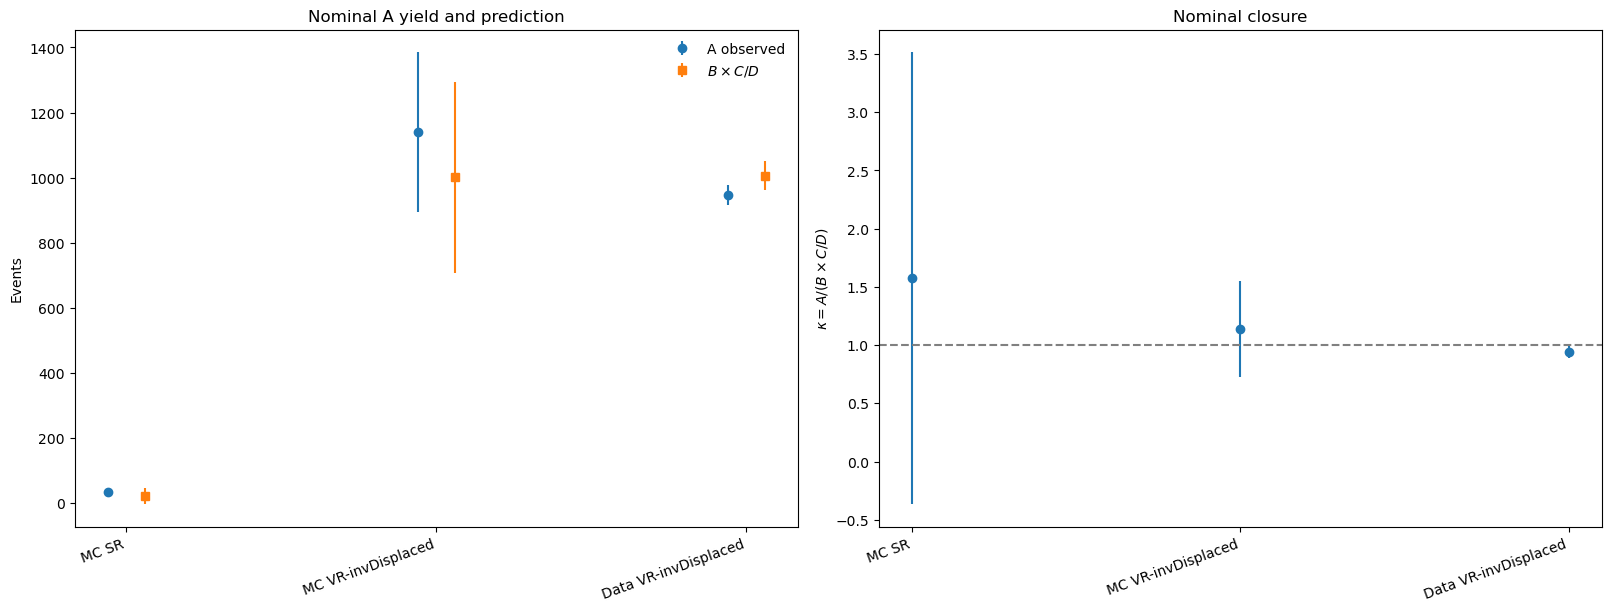

In [6]:
closure_columns = [
    "sample", "A_yield", "A_error", "A_pred", "A_pred_err",
    "kappa", "kappa_err", "pull",
]
display(nominal_summary[closure_columns])

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
positions = np.arange(len(nominal_summary))
axes[0].errorbar(positions - 0.06, nominal_summary.A_yield,
                 yerr=nominal_summary.A_error, fmt="o", label="A observed")
axes[0].errorbar(positions + 0.06, nominal_summary.A_pred,
                 yerr=nominal_summary.A_pred_err, fmt="s", label=r"$B \times C / D$")
axes[0].set(ylabel="Events", title="Nominal A yield and prediction")
axes[0].legend(frameon=False)
axes[1].errorbar(positions, nominal_summary.kappa, yerr=nominal_summary.kappa_err, fmt="o")
axes[1].axhline(1, color="gray", linestyle="--")
axes[1].set(ylabel=r"$\kappa=A/(B \times C/D)$", title="Nominal closure")
for ax in axes:
    ax.set_xticks(positions, nominal_summary["sample"], rotation=20, ha="right")


## 5. One-axis threshold scans

One isolation threshold is fixed at its nominal value while the other is scanned over 0.25, 0.30, 0.40, 0.50, 0.60, 0.75, and 1.00. All scan points are correlated cumulative selections.

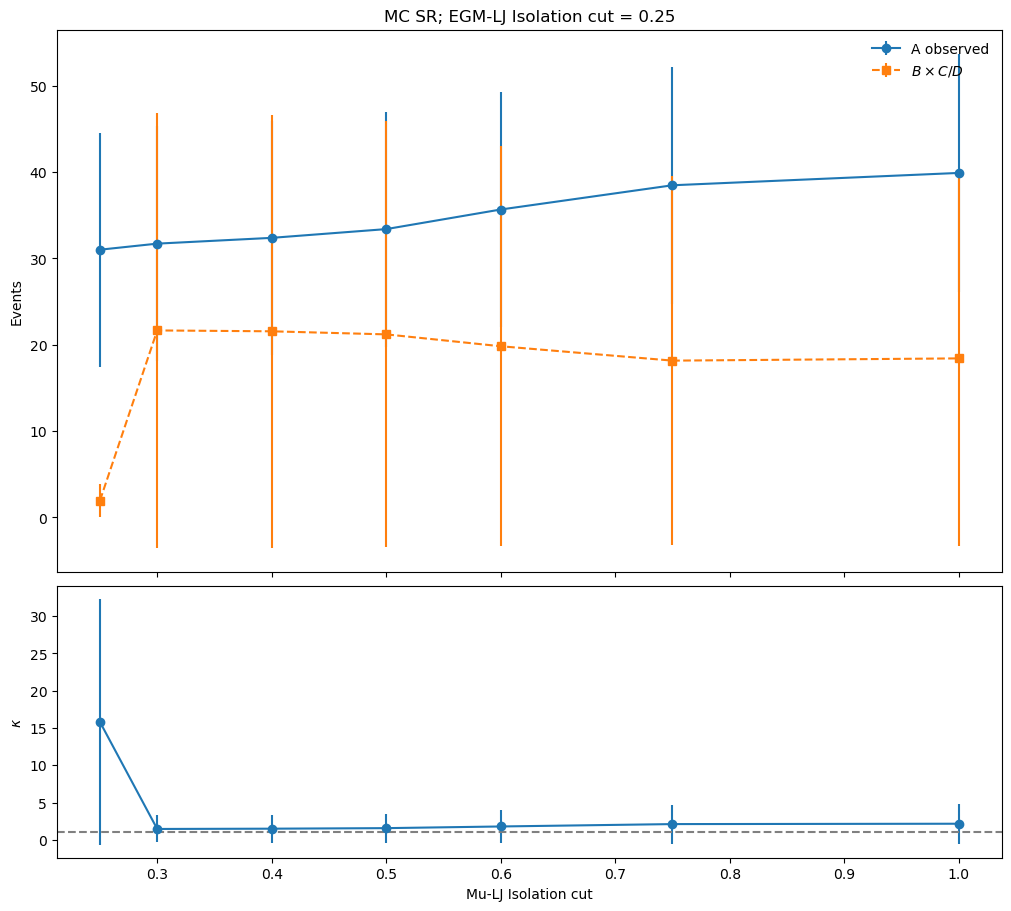

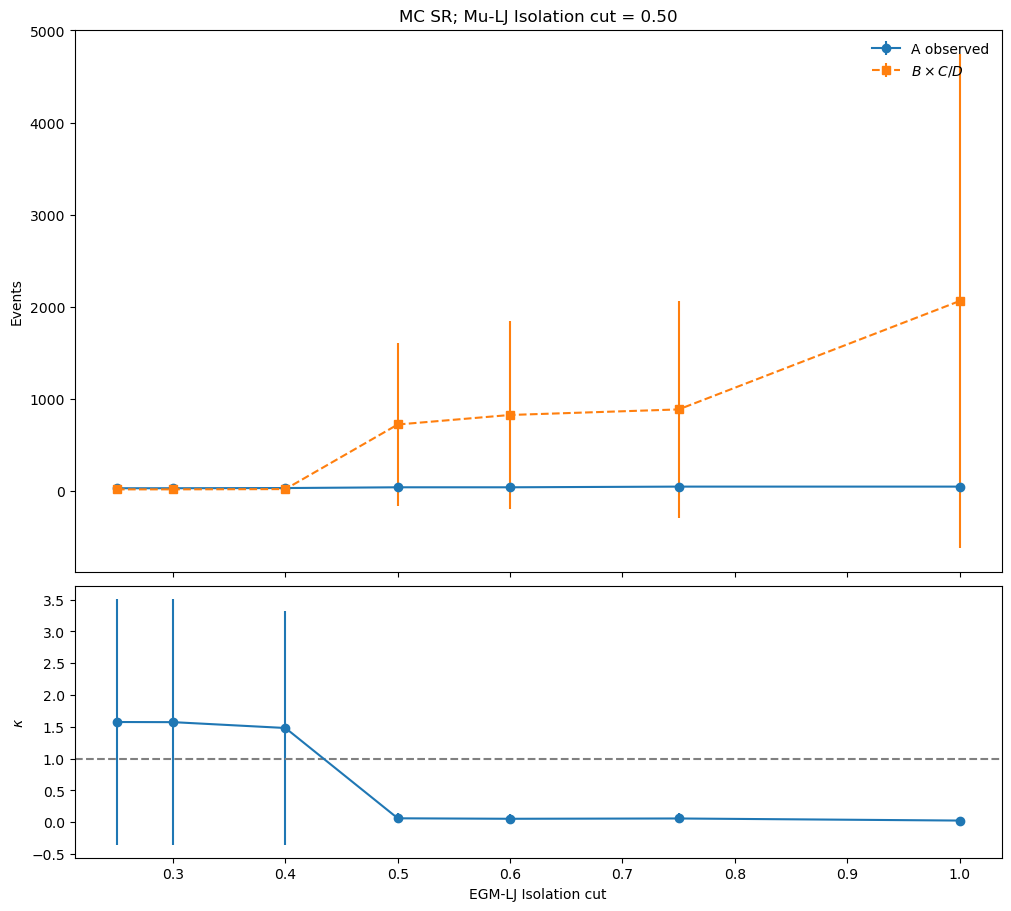

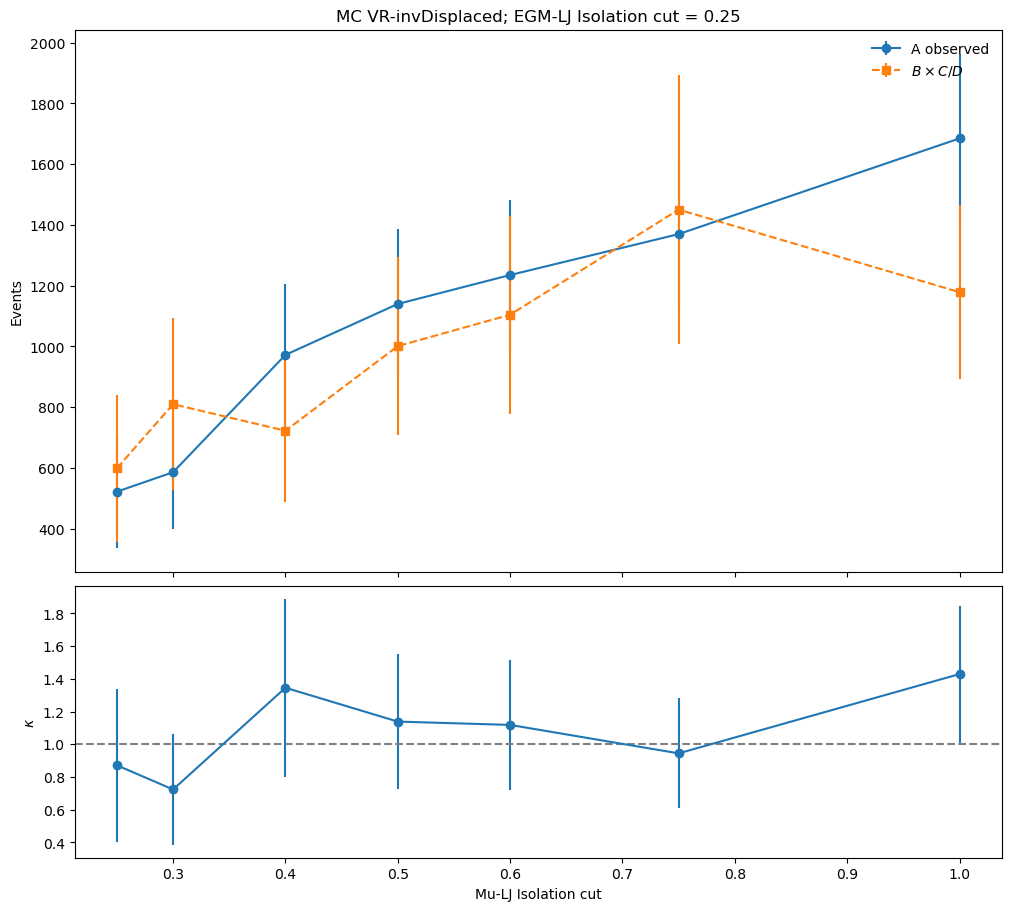

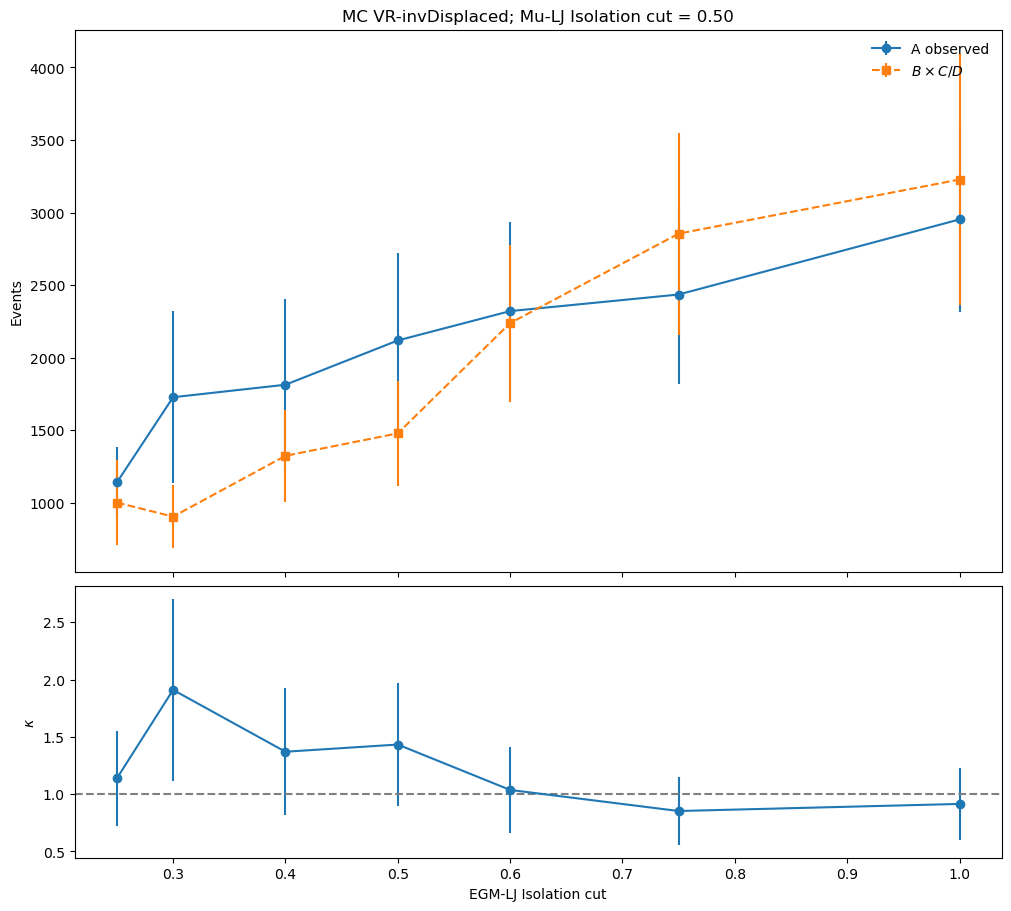

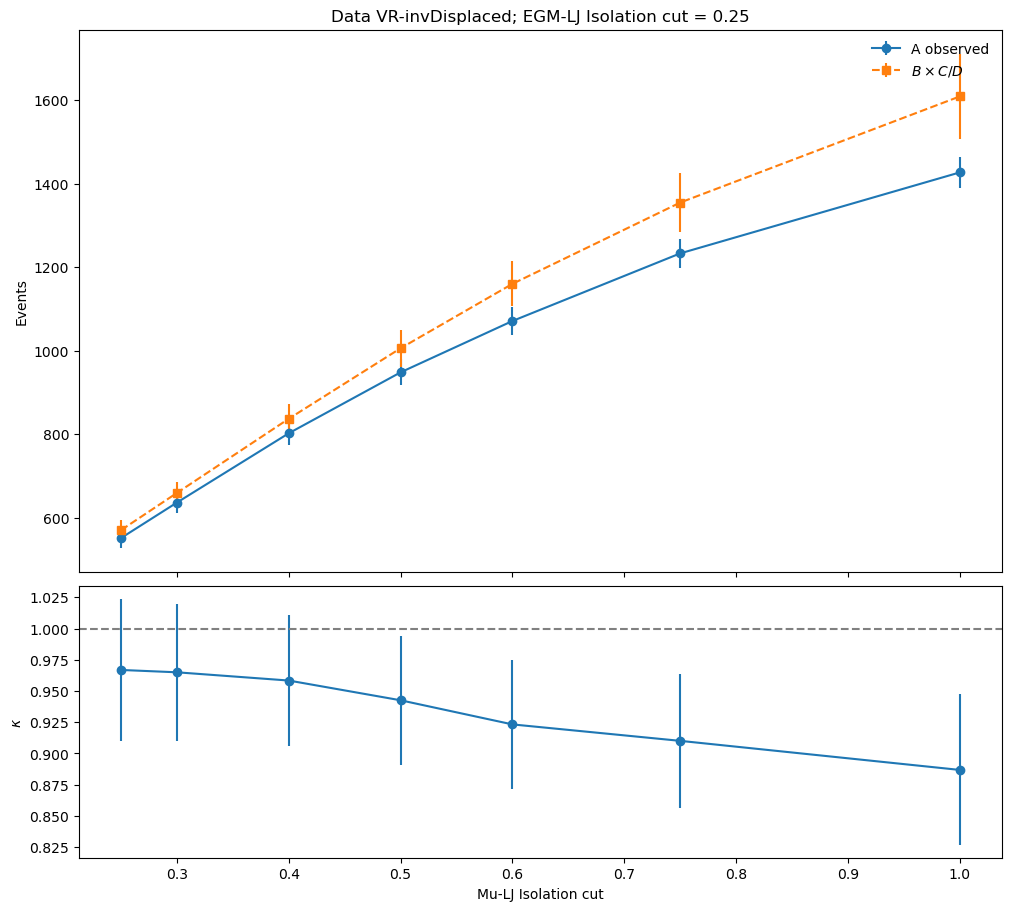

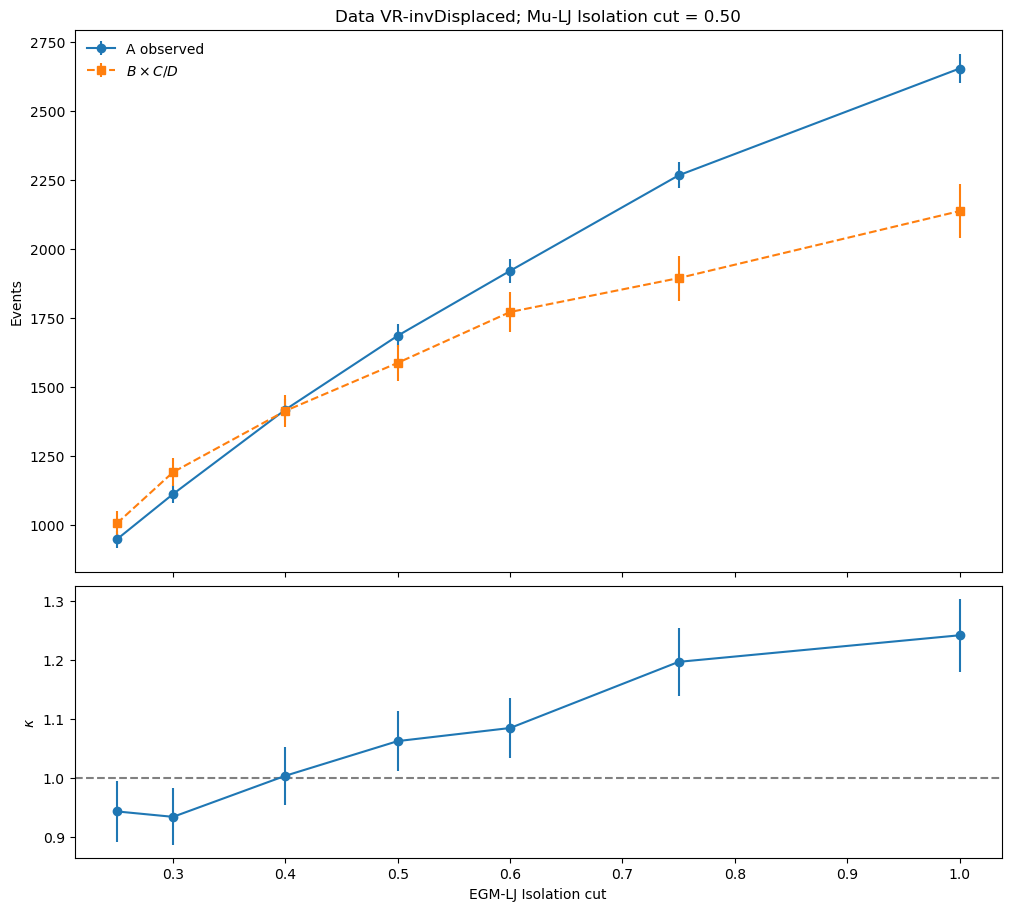

In [7]:
def scan_one_axis(h2d, scan_axis):
    rows = []
    for scan_cut in SCAN_VALUES:
        cuts = ((scan_cut, NOMINAL_CUTS[1]) if scan_axis == "x"
                else (NOMINAL_CUTS[0], scan_cut))
        rows.append(closure_row(h2d, cuts))
    return pd.DataFrame(rows)

def plot_one_axis_scan(frame, scan_label, fixed_label, fixed_value, title):
    fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True,
                             gridspec_kw={"height_ratios": [2, 1]},
                             constrained_layout=True)
    axes[0].errorbar(frame["xcut"] if scan_label == X_LABEL else frame["ycut"],
                     frame.A_yield, yerr=frame.A_error, fmt="o-", label="A observed")
    axes[0].errorbar(frame["xcut"] if scan_label == X_LABEL else frame["ycut"],
                     frame.A_pred, yerr=frame.A_pred_err, fmt="s--", label=r"$B \times C/D$")
    axes[0].set(ylabel="Events", title=f"{title}; {fixed_label} cut = {fixed_value:.2f}")
    axes[0].legend(frameon=False)
    scan_coordinate = frame["xcut"] if scan_label == X_LABEL else frame["ycut"]
    axes[1].errorbar(scan_coordinate, frame.kappa, yerr=frame.kappa_err, fmt="o-")
    axes[1].axhline(1, color="gray", linestyle="--")
    axes[1].set(xlabel=f"{scan_label} cut", ylabel=r"$\kappa$")
    return fig

one_axis_scans = {}
for selection, group, label in TARGETS:
    hist = group_hist(group, selection)
    for scan_axis, scan_label, fixed_label, fixed_value in [
        ("x", X_LABEL, Y_LABEL, NOMINAL_CUTS[1]),
        ("y", Y_LABEL, X_LABEL, NOMINAL_CUTS[0]),
    ]:
        frame = scan_one_axis(hist, scan_axis)
        one_axis_scans[(label, scan_axis)] = frame
        plot_one_axis_scan(frame, scan_label, fixed_label, fixed_value, label)
        plt.show(); plt.close()


## 6. Two-dimensional threshold scans

Both thresholds are varied over the allowed grid. Heatmaps show closure, pull, prediction uncertainty, and the minimum effective statistics among A/B/C/D. These grid points are correlated and are treated as robustness checks, not independent tests.

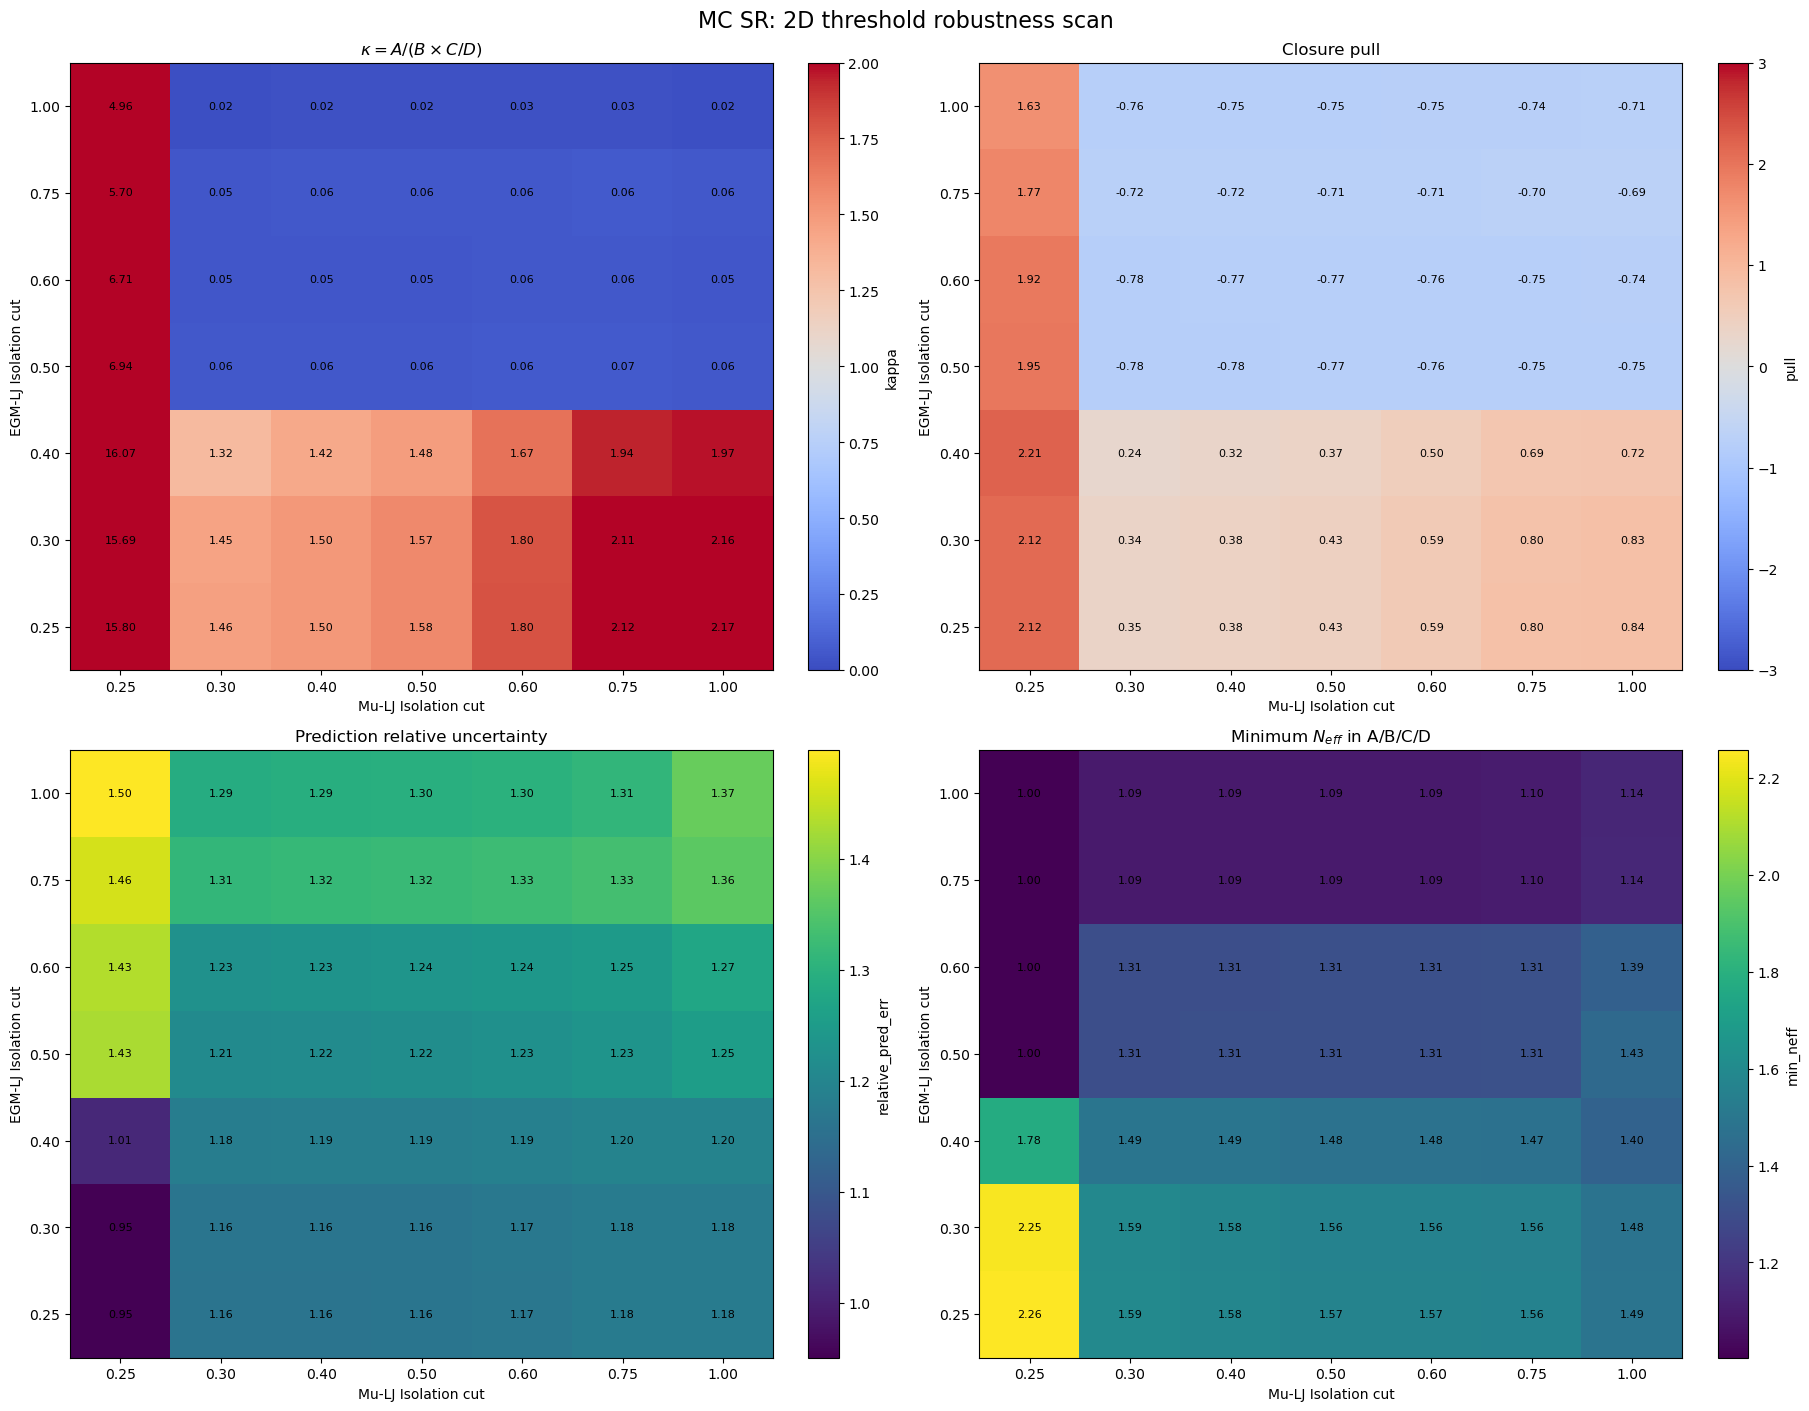

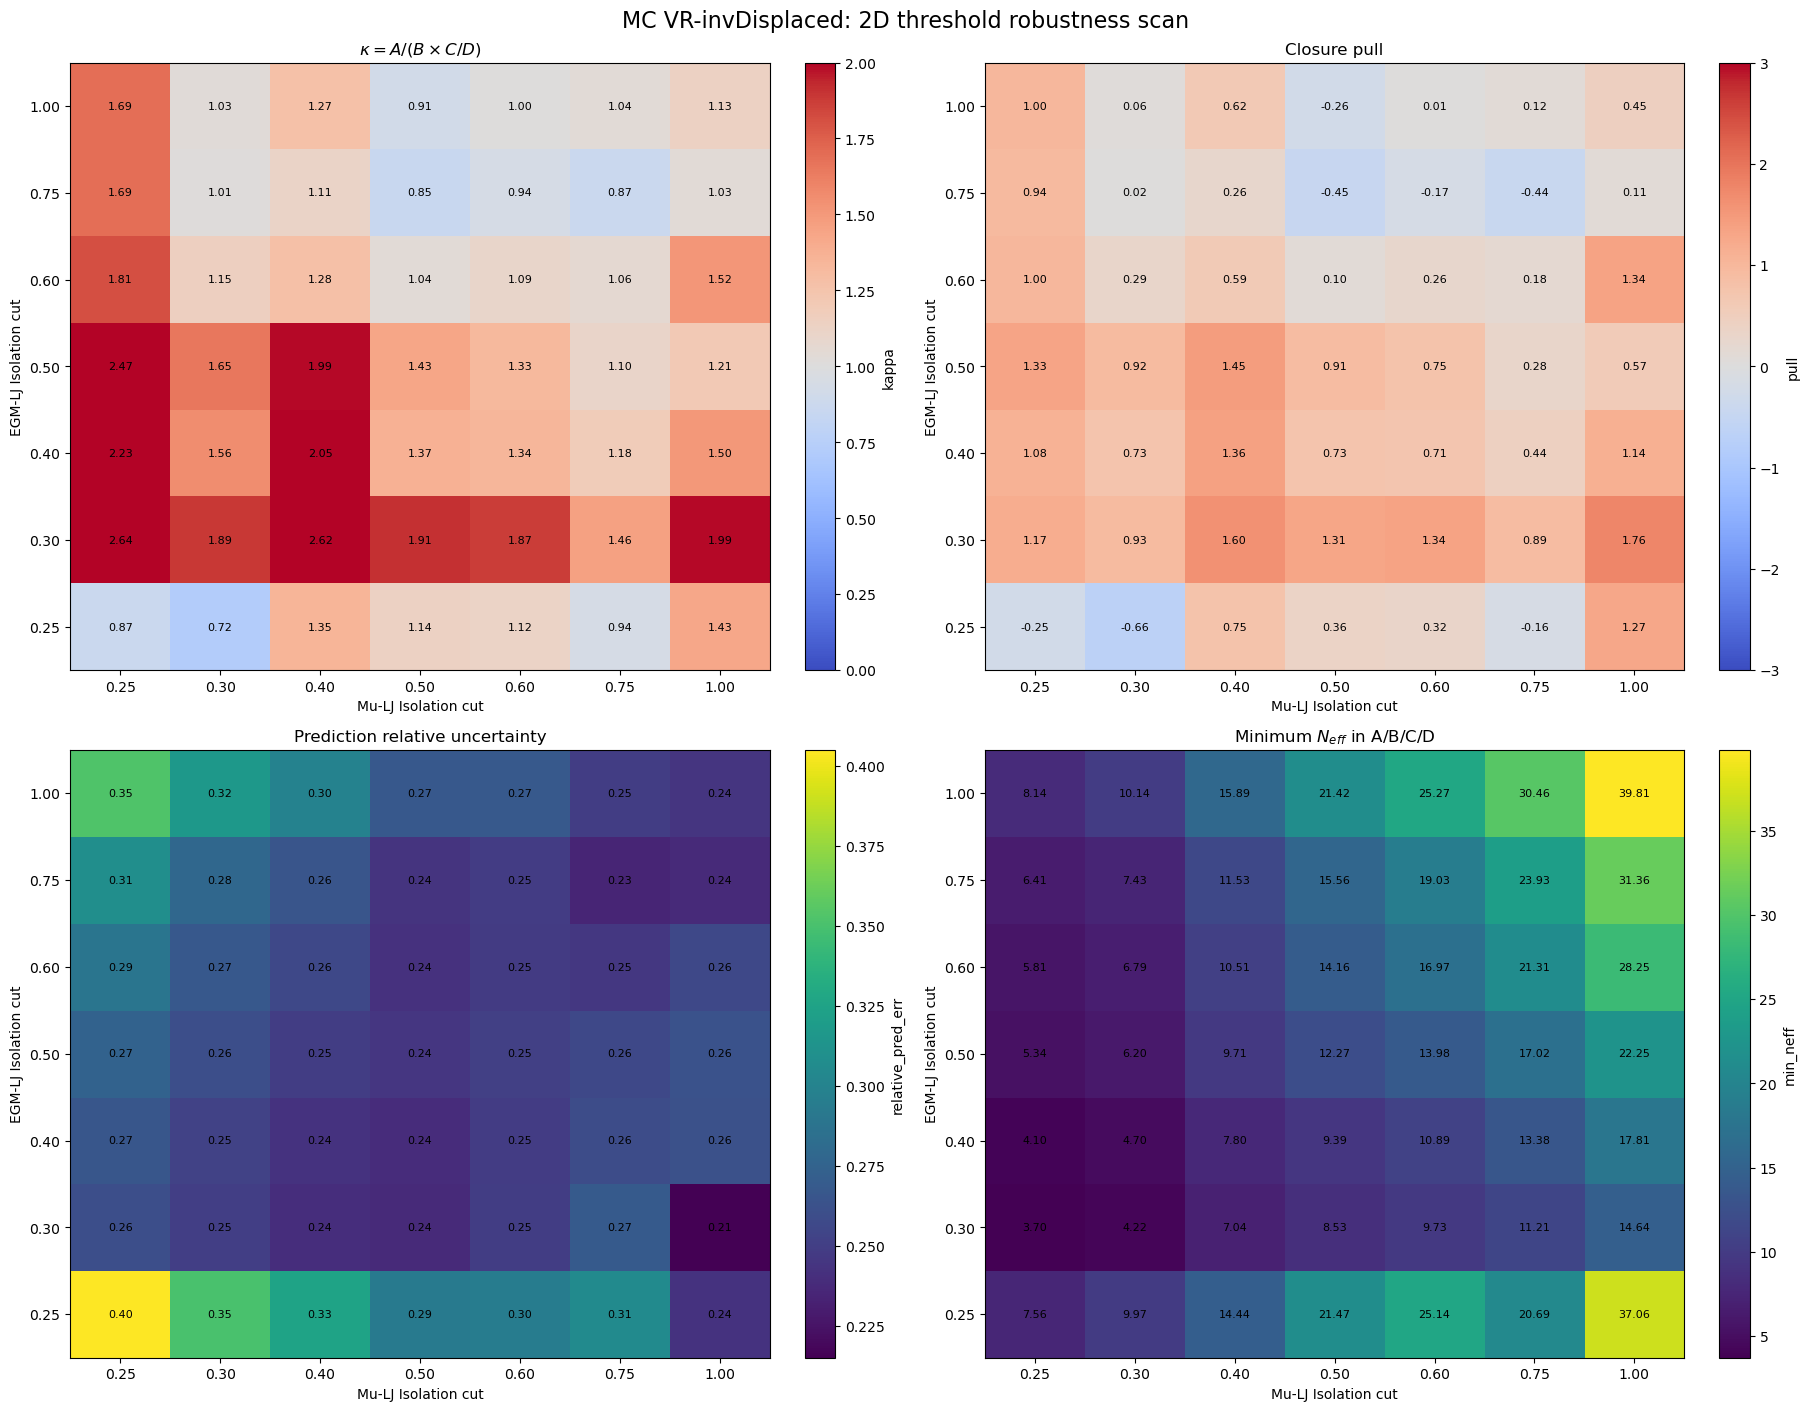

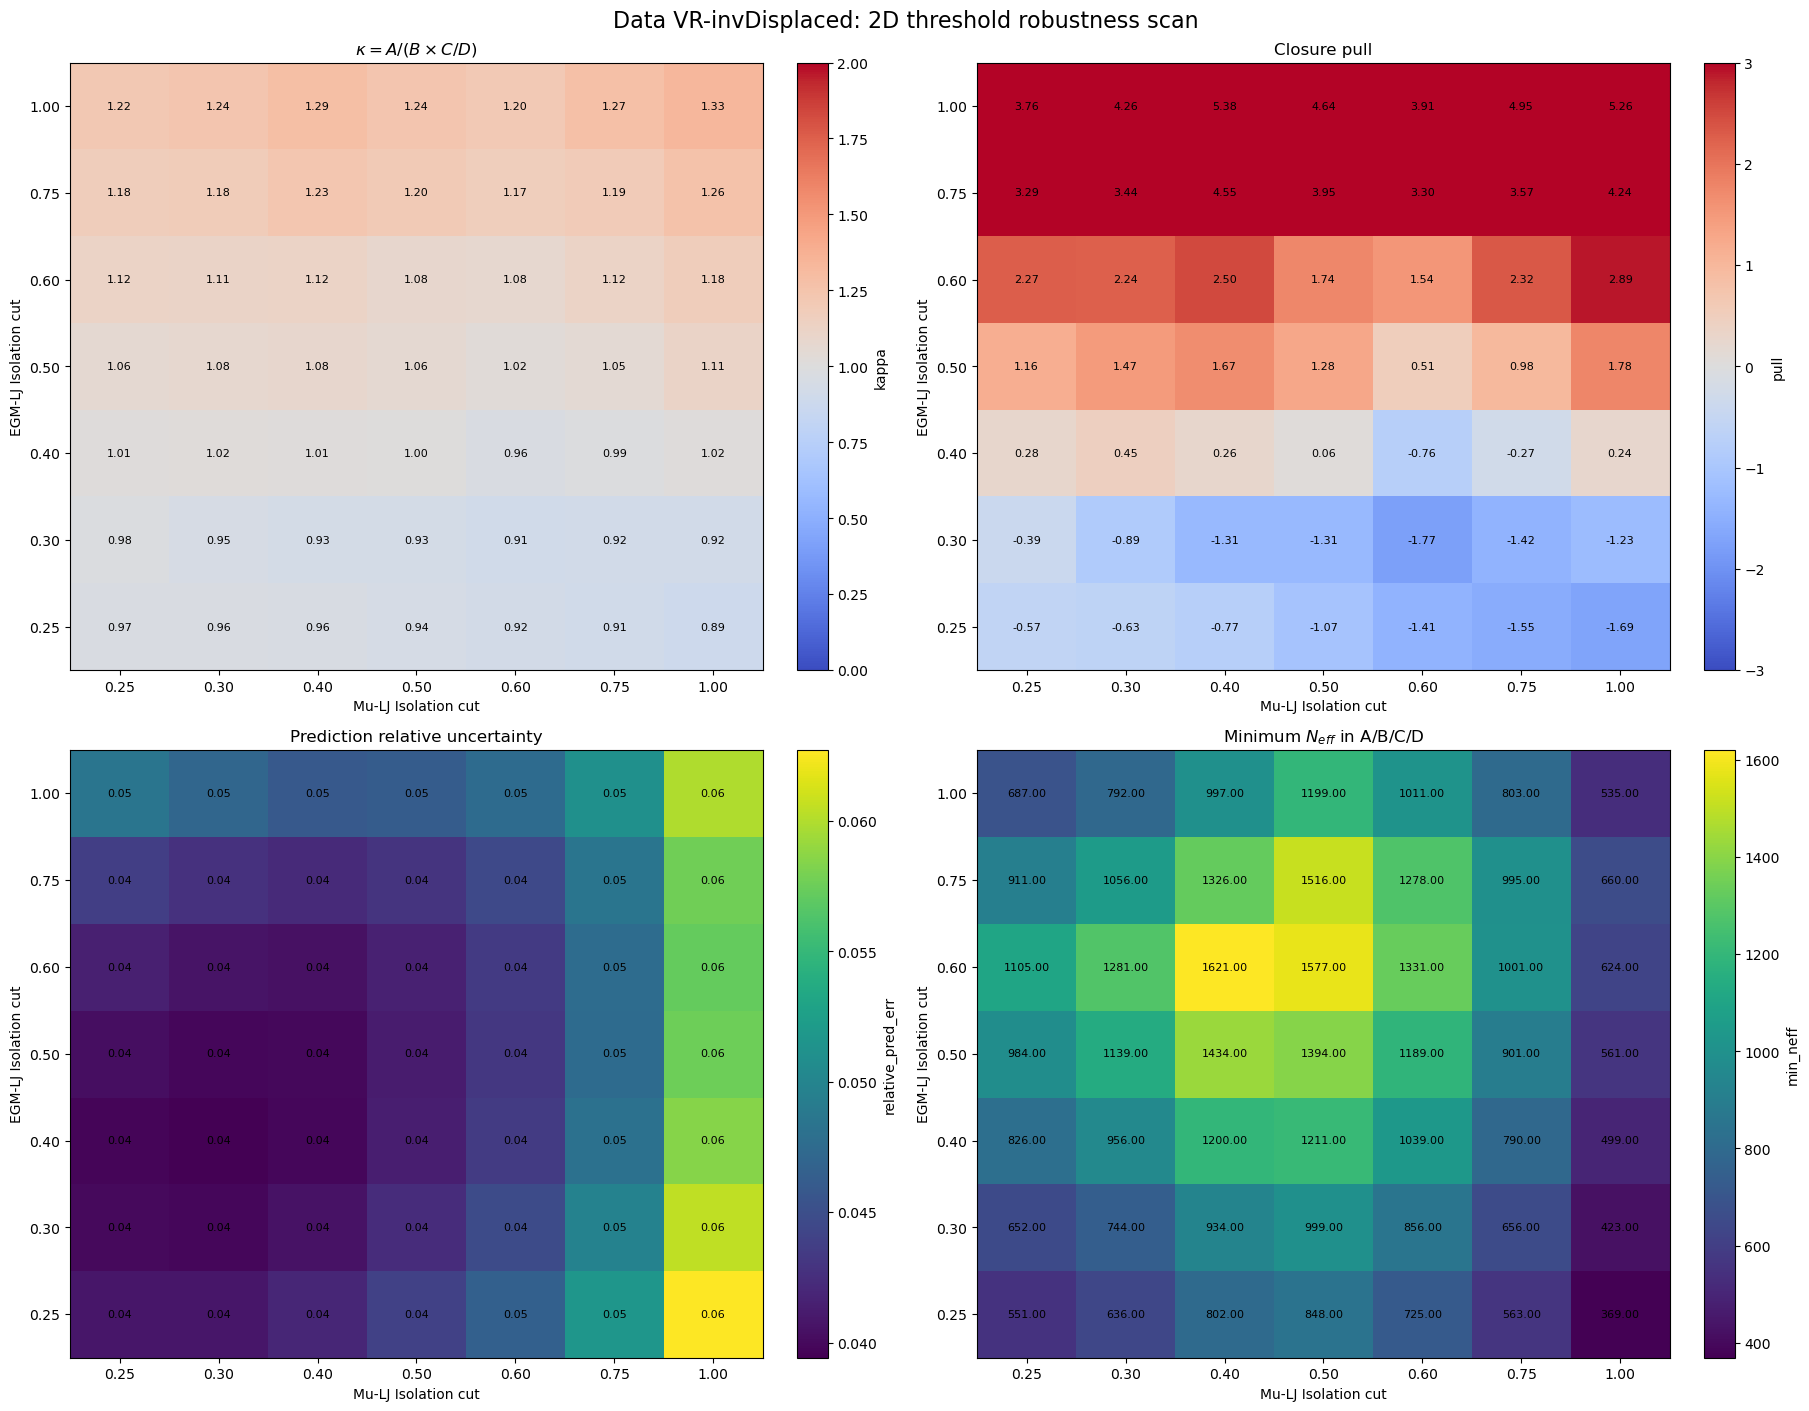

In [8]:
def scan_two_axes(h2d):
    return pd.DataFrame(
        closure_row(h2d, (xcut, ycut))
        for xcut in SCAN_VALUES for ycut in SCAN_VALUES
    )

def draw_heatmap(ax, frame, value, title, cmap="viridis", vmin=None, vmax=None):
    table = frame.pivot(index="ycut", columns="xcut", values=value)
    image = ax.imshow(table.values, origin="lower", aspect="auto",
                      cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(table.columns)), [f"{x:.2f}" for x in table.columns])
    ax.set_yticks(range(len(table.index)), [f"{y:.2f}" for y in table.index])
    ax.set(xlabel=f"{X_LABEL} cut", ylabel=f"{Y_LABEL} cut", title=title)
    for row_index, ycut in enumerate(table.index):
        for column_index, xcut in enumerate(table.columns):
            value_here = table.loc[ycut, xcut]
            label = f"{value_here:.2f}" if np.isfinite(value_here) else "nan"
            ax.text(column_index, row_index, label, ha="center", va="center", fontsize=8)
    plt.colorbar(image, ax=ax, label=value)

two_axis_scans = {}
for selection, group, label in TARGETS:
    frame = scan_two_axes(group_hist(group, selection))
    two_axis_scans[label] = frame
    fig, axes = plt.subplots(2, 2, figsize=(18, 14), constrained_layout=True)
    draw_heatmap(axes[0, 0], frame, "kappa", r"$\kappa=A/(B \times C/D)$",
                 cmap="coolwarm", vmin=0, vmax=2)
    draw_heatmap(axes[0, 1], frame, "pull", "Closure pull",
                 cmap="coolwarm", vmin=-3, vmax=3)
    draw_heatmap(axes[1, 0], frame, "relative_pred_err",
                 "Prediction relative uncertainty")
    draw_heatmap(axes[1, 1], frame, "min_neff", r"Minimum $N_{eff}$ in A/B/C/D")
    fig.suptitle(f"{label}: 2D threshold robustness scan", fontsize=16)
    plt.show(); plt.close(fig)


## 7. Scan tables and MC statistical diagnostics

In [9]:
scan_columns = [
    "xcut", "ycut", "A_yield", "A_error", "A_pred", "A_pred_err",
    "kappa", "kappa_err", "pull", "relative_pred_err", "min_neff",
]
for label, frame in two_axis_scans.items():
    print(label)
    display(frame[scan_columns])

mc_neff_columns = ["sample"] + [f"{region}_neff" for region in "ABCD"]
mc_neff_columns += ["A_error", "A_pred_err", "relative_pred_err"]
display(nominal_summary[nominal_summary["sample"].str.startswith("MC")][mc_neff_columns])


MC SR


,xcut,ycut,A_yield,A_error,A_pred,A_pred_err,kappa,kappa_err,pull,relative_pred_err,min_neff
0,0.25,0.25,31.003767,13.552784,1.962007,1.865866,15.802071,16.539297,2.122839,0.950999,2.258404
1,0.25,0.30,31.032941,13.552816,1.977844,1.882543,15.690285,16.431257,2.123455,0.951815,2.247595
2,0.25,0.40,32.447346,13.585118,2.019329,2.045684,16.068381,17.613523,2.214835,1.013051,1.777258
3,0.25,0.50,39.868429,15.435563,5.742829,8.211340,6.942298,10.283847,1.951843,1.429842,1.003143
4,0.25,0.60,39.868429,15.435563,5.944347,8.525363,6.706949,9.963410,1.923849,1.434197,1.003143
5,0.25,0.75,39.868429,15.435563,6.997847,10.233851,5.697242,8.618841,1.774875,1.462429,1.003143
6,0.25,1.00,39.868429,15.435563,8.032882,12.035559,4.963154,7.680482,1.626484,1.498287,1.003143
7,0.30,0.25,31.705333,13.568816,21.654452,25.168193,1.464148,1.813425,0.351517,1.162264,1.591882
8,0.30,0.30,31.763682,13.568879,21.866242,25.430887,1.452636,1.799804,0.343371,1.163020,1.589820
9,0.30,0.40,33.178087,13.601143,25.222720,29.852416,1.315405,1.647594,0.242506,1.183553,1.490865


MC VR-invDisplaced


,xcut,ycut,A_yield,A_error,A_pred,A_pred_err,kappa,kappa_err,pull,relative_pred_err,min_neff
0,0.25,0.25,522.082398,184.791147,599.098679,242.558931,0.871446,0.468643,-0.252570,0.404873,7.562783
1,0.25,0.30,1094.419127,568.792998,415.187515,108.288719,2.635963,1.532800,1.173092,0.260819,3.702191
2,0.25,0.40,1152.914568,569.188421,517.941432,137.797253,2.225955,1.248355,1.084255,0.266048,4.102817
3,0.25,0.50,1335.471314,578.041158,541.333952,148.704468,2.467001,1.264703,1.330520,0.274700,5.337669
4,0.25,0.60,1394.082532,578.377544,772.254435,222.813337,1.805211,0.912251,1.003253,0.288523,5.809706
5,0.25,0.75,1464.875579,578.800422,865.309954,267.016137,1.692891,0.848711,0.940609,0.308579,6.405364
6,0.25,1.00,1676.841304,587.710847,991.795826,349.679961,1.690712,0.840521,1.001717,0.352573,8.140602
7,0.30,0.25,586.043390,185.577076,809.919900,283.917933,0.723582,0.341819,-0.660037,0.350551,9.972657
8,0.30,0.30,1169.106602,569.105418,619.805699,155.126815,1.886247,1.032456,0.931225,0.250283,4.220100
9,0.30,0.40,1235.057442,569.547770,793.421873,199.979081,1.556621,0.818060,0.731626,0.252046,4.702340


Data VR-invDisplaced


,xcut,ycut,A_yield,A_error,A_pred,A_pred_err,kappa,kappa_err,pull,relative_pred_err,min_neff
0,0.25,0.25,551.0,23.473389,569.894366,23.259684,0.966846,0.057041,-0.571766,0.040814,551.0
1,0.25,0.30,652.0,25.534291,666.575906,26.681770,0.978133,0.054775,-0.394677,0.040028,652.0
2,0.25,0.40,826.0,28.740216,814.053925,32.362365,1.014675,0.053606,0.276006,0.039755,826.0
3,0.25,0.50,984.0,31.368774,927.374868,37.379453,1.061060,0.054527,1.160404,0.040307,984.0
4,0.25,0.60,1136.0,33.704599,1013.596117,41.996370,1.120762,0.057115,2.273103,0.041433,1105.0
5,0.25,0.75,1330.0,36.469165,1127.806437,49.381572,1.179280,0.060925,3.293675,0.043786,911.0
6,0.25,1.00,1554.0,39.420807,1278.074739,61.909600,1.215891,0.066485,3.759465,0.048440,687.0
7,0.30,0.25,636.0,25.219040,659.090909,26.904029,0.964966,0.054915,-0.626180,0.040820,636.0
8,0.30,0.30,744.0,27.276363,780.779535,31.079484,0.952894,0.051567,-0.889440,0.039806,744.0
9,0.30,0.40,956.0,30.919250,934.220624,36.825463,1.023313,0.052177,0.452940,0.039418,956.0


,sample,A_neff,B_neff,C_neff,D_neff,A_error,A_pred_err,relative_pred_err
0,MC SR,6.025864,9.451499,1.644767,1.566504,13.601789,24.650043,1.162823
1,MC VR-invDisplaced,21.580418,37.739506,21.471763,79.979114,245.392112,292.861611,0.292529
